In [6]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as m 
import seaborn as sns                   #for statistical visualization
import statsmodels.api as sm           #for statistical modeling 
#importing seasonal_decompose for time series analysis 
from statsmodels.tsa.seasonal import seasonal_decompose




In [7]:
#for the graph outputs
#setting matplotlib to default settings
plt.style.use('default')

In [8]:
#allowing all columns to display without truncation
pd.set_option('display.max_columns', 500)
#auto-adjusting pandas display width
pd.set_option('display.width', None)

In [9]:
#setting default figure size for visible graphs
m.rcParams['figure.figsize']= (12,6)

In [10]:
#setting font size for axis labels and tick labels
m.rcParams['axes.labelsize'] = 12
m.rcParams['xtick.labelsize'] = 10
m.rcParams['ytick.labelsize'] = 10 
#making axis titles bold for better emphasis
m.rcParams['axes.titleweight'] = 'bold'

In [11]:
#making changes for visibility
m.rcParams['text.color'] = 'black' 
m.rcParams['lines.linewidth'] = 1.5

In [12]:
#setting axis lines: thin, light gray
m.rcParams['axes.axisbelow'] = True
m.rcParams['axes.grid'] = False
m.rcParams['axes.linewidth'] = 1 
m.rcParams['axes.edgecolor'] = 'gray'

In [13]:
#let's add custom grid
m.rcParams['grid.color'] = 'gray'
m.rcParams['grid.linestyle'] = "--"
m.rcParams['grid.linewidth'] = 1
m.rcParams['grid.alpha'] = 0.5

In [14]:
#load the data
df = pd.read_excel('electricity2025.xlsx', header=None)
df = df.iloc[:,[0,-1]]
#visualize data
print(df)

          0       5
0   2025-01  361981
1   2025-02  320561
2   2025-03  307241
3   2025-04  294846
4   2025-05  312489
5   2025-06  357100
6   2025-07  407630
7   2025-08  392631
8   2025-09  346202
9   2025-10  320588
10  2025-11  299022
11  2025-12  337716


In [15]:
#rename the columns that was given default column names
df.columns = ['Month', 'all_sectors_combined']


In [16]:
#display the data again
print(df)

      Month  all_sectors_combined
0   2025-01                361981
1   2025-02                320561
2   2025-03                307241
3   2025-04                294846
4   2025-05                312489
5   2025-06                357100
6   2025-07                407630
7   2025-08                392631
8   2025-09                346202
9   2025-10                320588
10  2025-11                299022
11  2025-12                337716


In [17]:
#summarize the data statistically
df.describe()

,all_sectors_combined
count,12.000000
mean,338167.250000
std,36213.476997
min,294846.000000
25%,311177.000000
50%,329152.000000
75%,358320.250000
max,407630.000000


In [18]:
#month with the highest energy consumption
df.max()

Month                   2025-12
all_sectors_combined     407630
dtype: object

In [19]:
print('Start of Time Period: {}\\nEnd of Time Period: {}'.format(  
df.Month.min(), df.Month.max()  
))

Start of Time Period: 2025-01\nEnd of Time Period: 2025-12


In [20]:
#shape of dataframe
df.shape

(12, 2)

In [21]:
type(df)

pandas.core.frame.DataFrame

In [22]:
df.head()

,Month,all_sectors_combined
0,2025-01,361981
1,2025-02,320561
2,2025-03,307241
3,2025-04,294846
4,2025-05,312489


In [23]:
df.dtypes

Month                   object
all_sectors_combined     int64
dtype: object

In [24]:
#months has to be changed from string to datetime format
#to apply time series techniques. 
df['Month'] = pd.to_datetime(df['Month'],format='%Y-%m')


In [25]:
print(df)

        Month  all_sectors_combined
0  2025-01-01                361981
1  2025-02-01                320561
2  2025-03-01                307241
3  2025-04-01                294846
4  2025-05-01                312489
5  2025-06-01                357100
6  2025-07-01                407630
7  2025-08-01                392631
8  2025-09-01                346202
9  2025-10-01                320588
10 2025-11-01                299022
11 2025-12-01                337716


In [26]:
#set 'Month' column as indez which will make future options easier
df_series = df.set_index('Month')
#view data
df_series.head()

,all_sectors_combined
Month,
2025-01-01,361981
2025-02-01,320561
2025-03-01,307241
2025-04-01,294846
2025-05-01,312489


In [27]:
#let's visualize our series index 
df_series.index

DatetimeIndex(['2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01',
               '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01',
               '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01'],
              dtype='datetime64[ns]', name='Month', freq=None)

In [28]:
#check for missing values
df_series.isnull().sum()

all_sectors_combined    0
dtype: int64

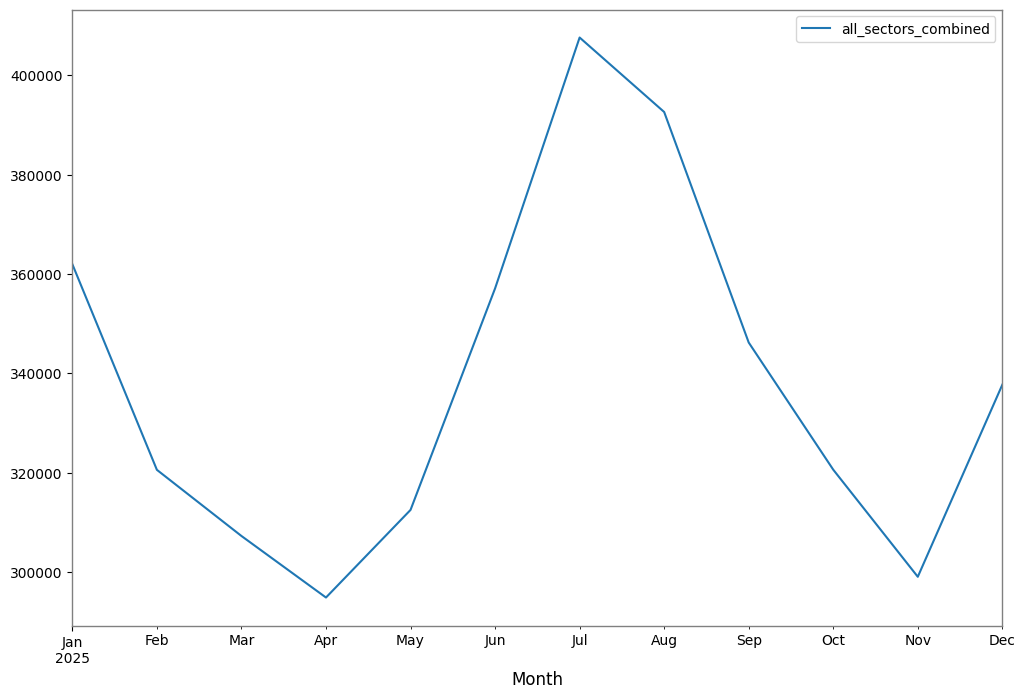

In [29]:
#let's plot the time series to see any trend
df_series.plot(figsize=(12,8))
plt.show()

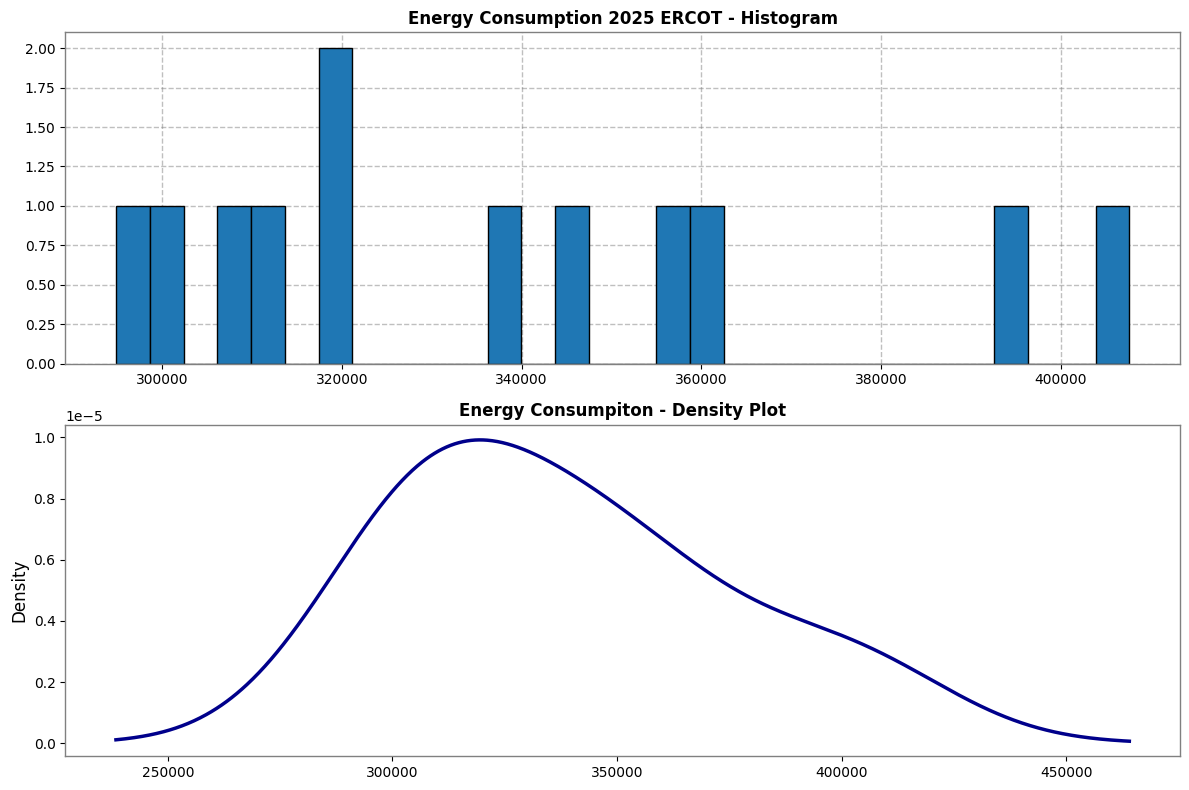

In [30]:
#plotting density analysis for energy consumption
plt.figure(figsize=(12,8))
#histogram to visualize frequency distribution
plt.subplot(2,1,1)
df_series['all_sectors_combined'].hist(bins=30, edgecolor='black')
plt.title('Energy Consumption 2025 ERCOT - Histogram')

#KDE plot to analyze distribution shape
plt.subplot(2,1,2)
df_series['all_sectors_combined'].plot(kind='kde', linewidth=2.5, color='darkblue')
plt.title('Energy Consumpiton - Density Plot')
plt.tight_layout()
plt.show()

In [31]:
#performing the multiplicative decomposition of the time series
decomposition_multiplic = sm.tsa.seasonal_decompose(
    df_series, period = 6, model='multiplicative', extrapolate_trend='freq')

In [32]:
#checking the object type of decomposition result
type(decomposition_multiplic)

statsmodels.tsa.seasonal.DecomposeResult

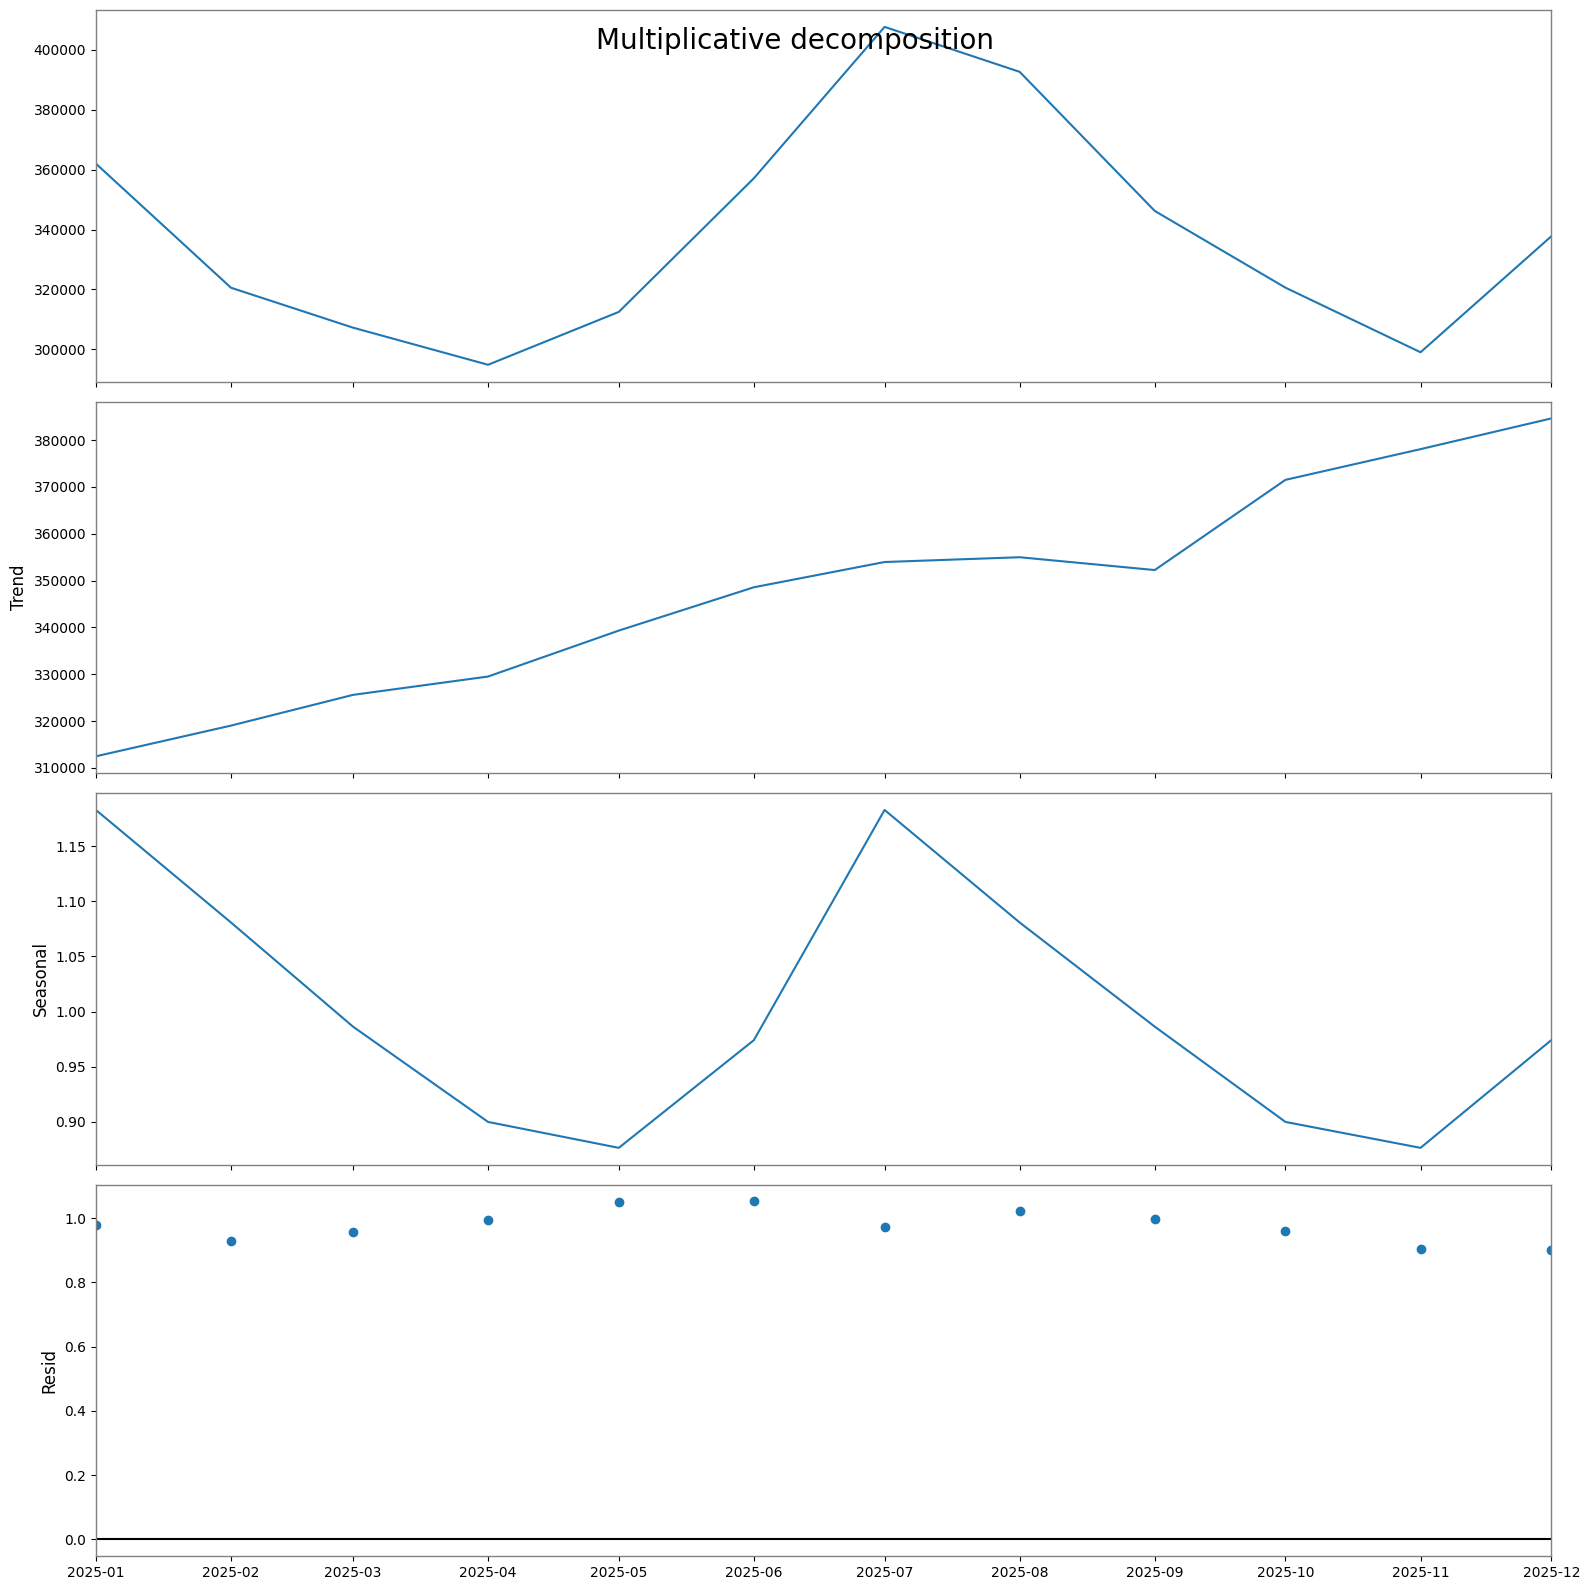

In [33]:
#plotting size
plt.rcParams.update({'figure.figsize': (16,16)})
#plot the multiplicative decomposition
decomposition_multiplic.plot().suptitle('Multiplicative decomposition', fontsize=20)
plt.show()

In [34]:
#let's perform additive decomposition of the time series to see 
#the results
decomposition_additive = sm.tsa.seasonal_decompose(df_series, model='additive', 
                                                  period=6,extrapolate_trend='freq')
type(decomposition_additive)

statsmodels.tsa.seasonal.DecomposeResult

<Figure size 1600x1600 with 0 Axes>

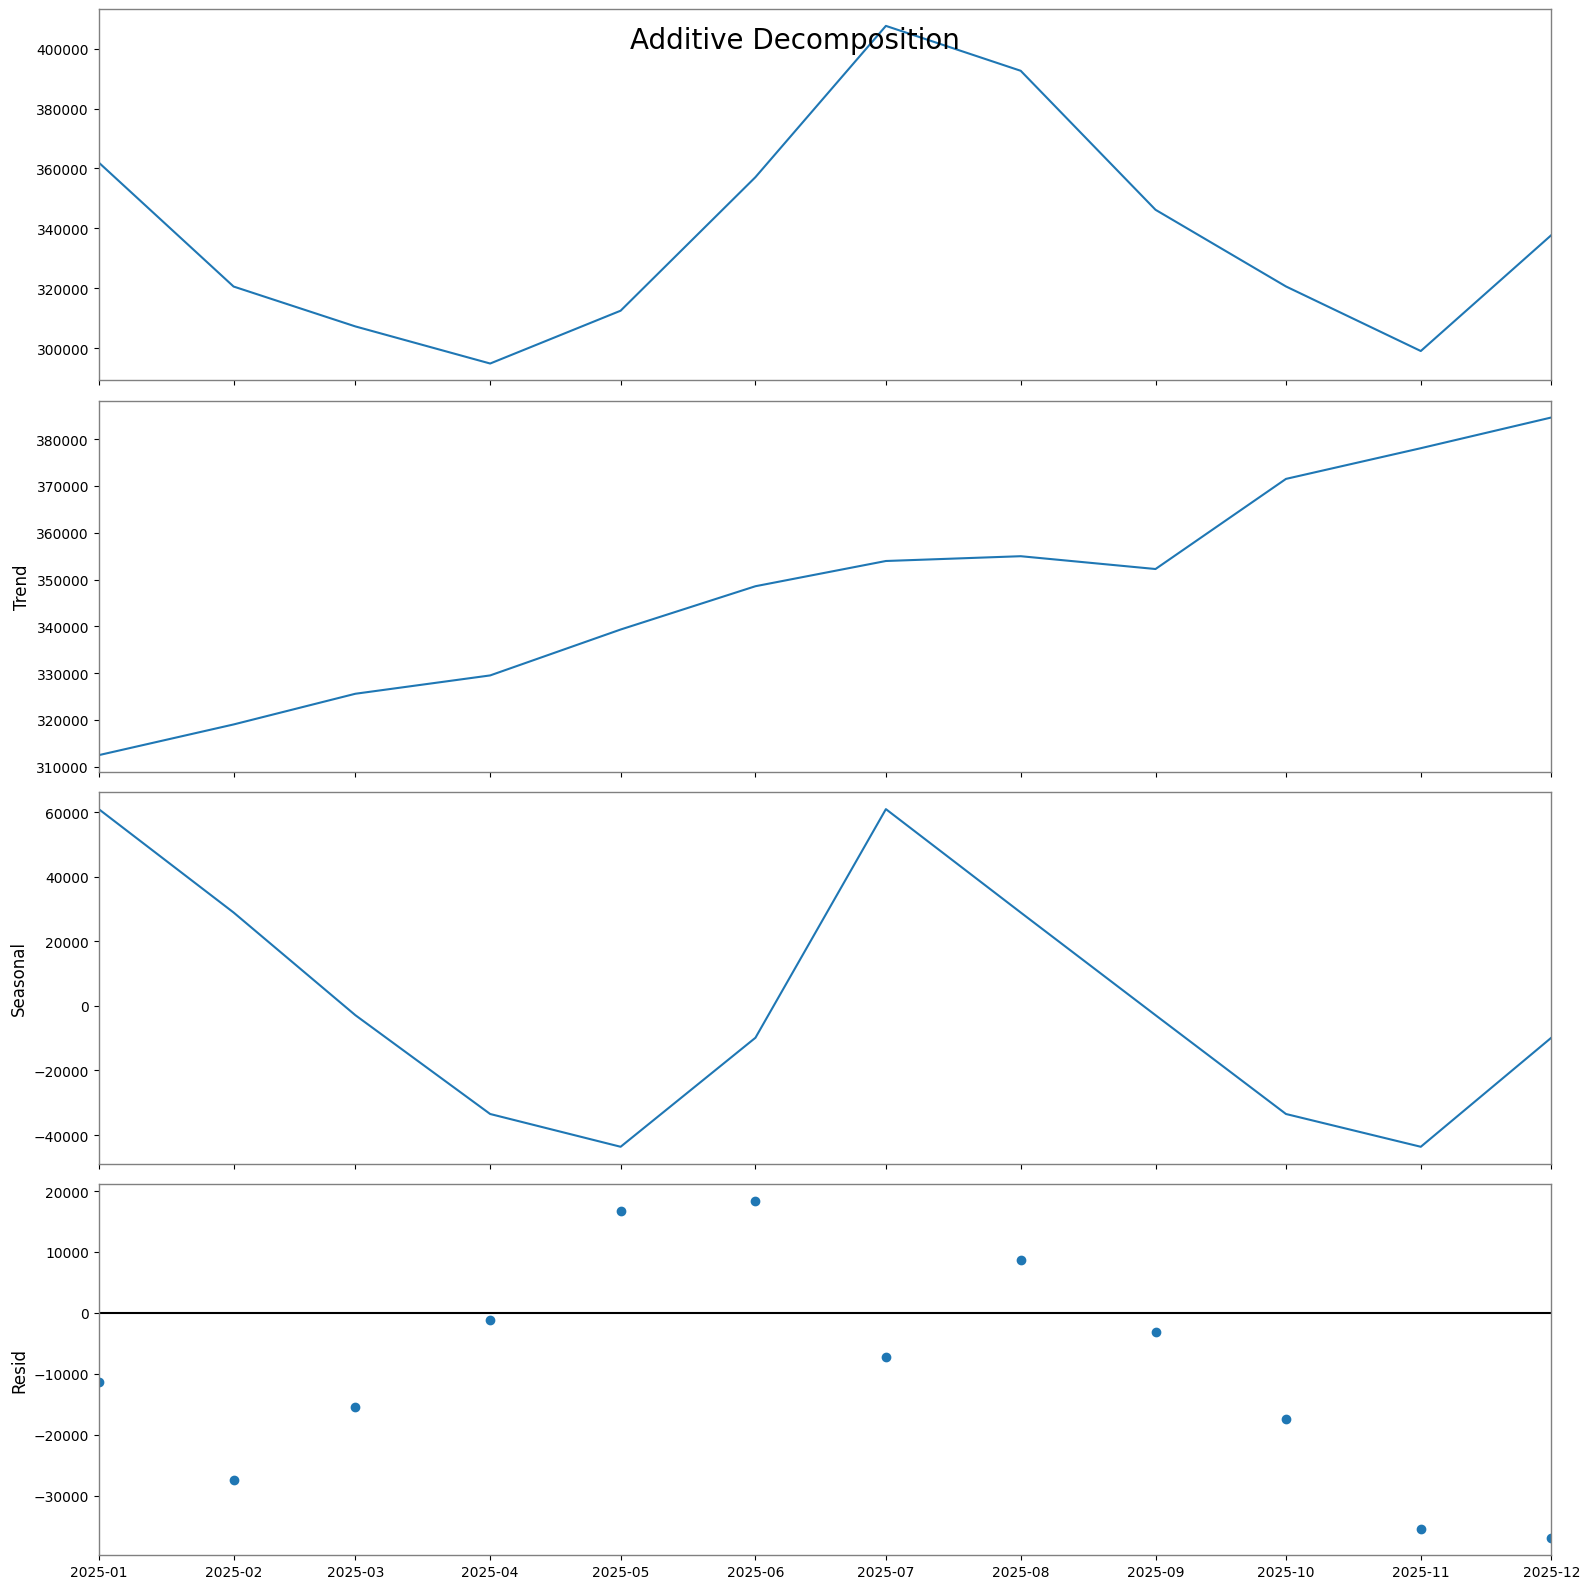

In [35]:
#time to plot again
plt.figure(figsize=(16,16))
#plotting the additive decomposition with title
fig = decomposition_additive.plot()
fig.suptitle('Additive Decomposition', fontsize=20)
plt.show()

In [36]:
#in this additive model(in the last figure), we can see clear ups and downs
#patterns which is not ideal for analysis and require transformations. 
#so, multiplicative decomposition is chosen. 

# By extracting the given components, we try to observe the mathematical formula:
    #Real values = seasonality * Trend * Residuals

In [37]:
#lets extract and validate this decomposition
#concatenate the decomposed components of the given time series
df_series_reconstructed = pd.concat(
    [
        decomposition_multiplic.seasonal,       #seasonal component
        decomposition_multiplic.trend,        #trend component
        decomposition_multiplic.resid,         #residual (noise) component
        decomposition_multiplic.observed     #observed (original) time series
    ], axis=1 
)

In [38]:
#renaming columns to reflect the decomposed components
df_series_reconstructed.columns =['Seasonality', 'Trend', 'Residuals', 
                                 'Observed_values']
df_series_reconstructed.head()

,Seasonality,Trend,Residuals,Observed_values
Month,,,,
2025-01-01,1.182681,312468.333333,0.979517,361981.0
2025-02-01,1.080686,319028.250000,0.929784,320561.0
2025-03-01,0.986296,325588.166667,0.956761,307241.0
2025-04-01,0.899906,329507.083333,0.994336,294846.0
2025-05-01,0.876412,339317.000000,1.050801,312489.0


In [39]:
observed_value = (1.182681*312468.333333*0.979517)
print(observed_value)

361980.86089158227


In [40]:
#The observed value obtained as the product confirms the mathematical 
#formula mentioned earlier.  

In [41]:
#starting the validation process of the time series now
#first checking type of datatset
type(df_series)

pandas.core.frame.DataFrame

In [42]:
#computing rolling statistics for trend analysis
#calculate 12 month moving average
rolling_mean = df_series['all_sectors_combined'].rolling(window=12).mean()

#calculate 12 month rolling standard deviation 
rolling_std = df_series['all_sectors_combined'].rolling(window=12).std()

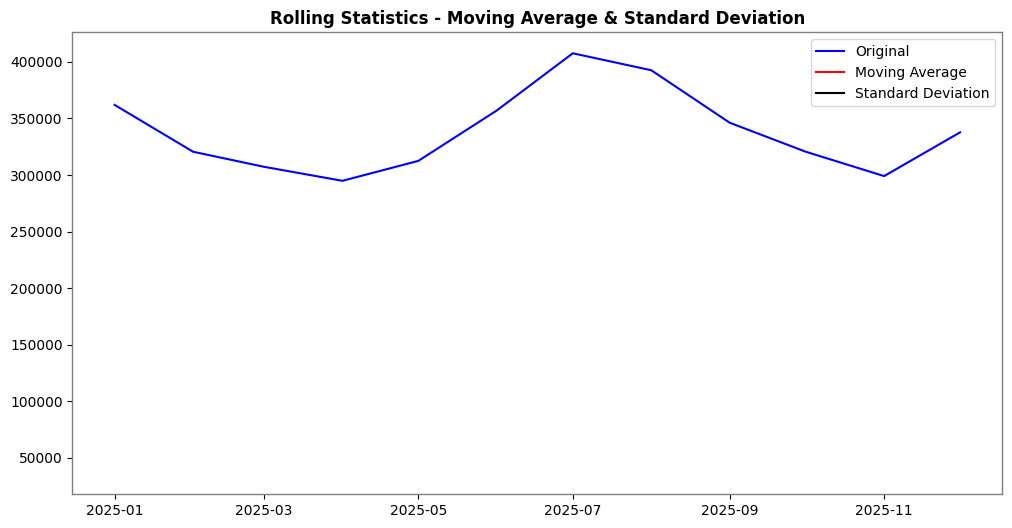

In [43]:
#plot rolling statistics for trend and variance analysis
plt.figure(figsize=(12,6))
#plot original time series values
plt.plot(df_series['all_sectors_combined'], color='blue', label='Original')

#plot moving average (rolling mean)
plt.plot(rolling_mean, color='red', label='Moving Average')

#plot rolling standard deviation
plt.plot(rolling_std, color='black', label='Standard Deviation')

#configure legend and title
plt.legend(loc='best')
plt.title('Rolling Statistics - Moving Average & Standard Deviation')
plt.show()

In [44]:
#this confirms the station is not stationary and it needs to be adjusted
#without the adjustment, any statistical model would be incorrect
#time to apply techniques now to transform the series into a stationary form 

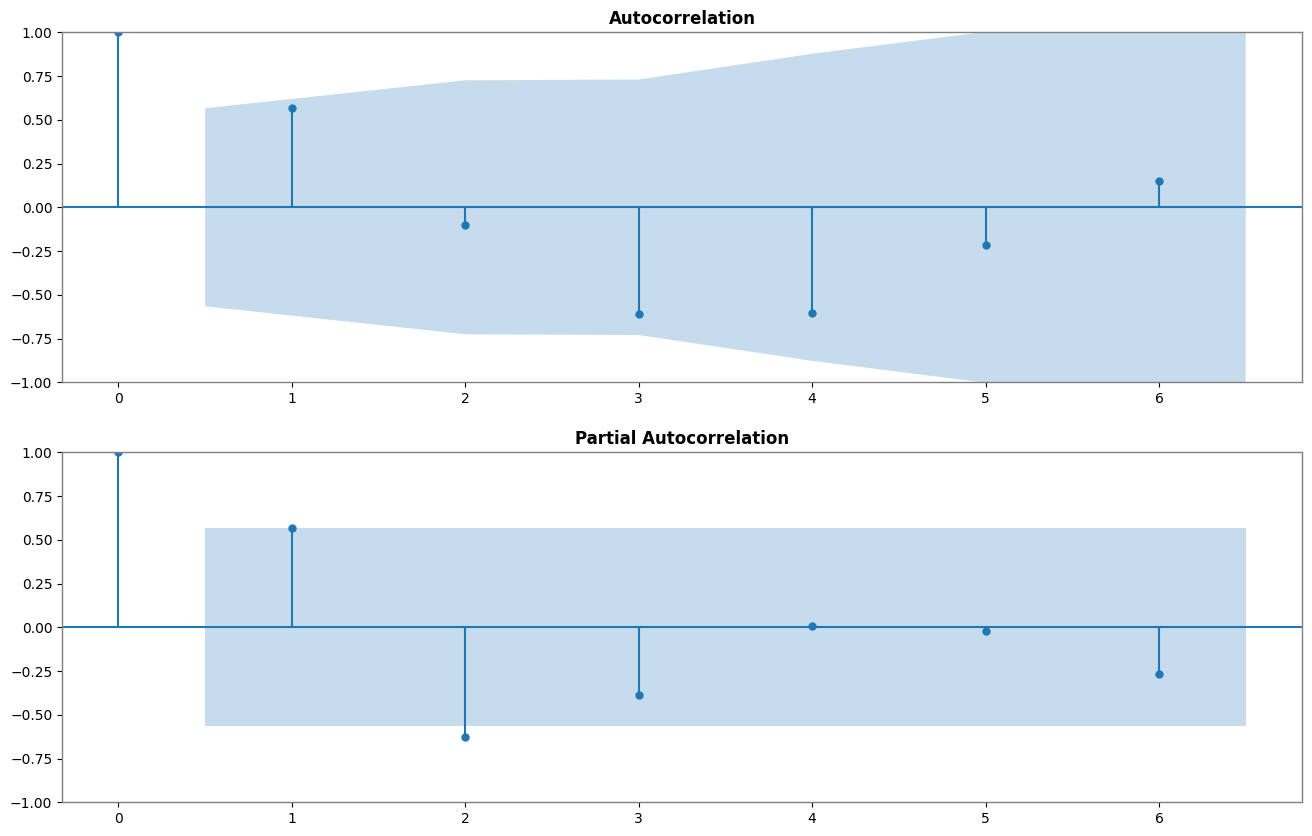

In [56]:
#to validate: we use ACF plot and PACF plot
#import functions for ACF and PACF plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#set global figure size for visualization
plt.rcParams.update({'figure.figsize': (16,10)})

#plot the ACF
#define subplot for ACF plot
plt.subplot(2,1,1)
#generate ACF plot with 6 lags
plot_acf(df_series['all_sectors_combined'], ax=plt.gca(), lags=6)
#------------------------------------------------------------------
#plot the pacf
plt.subplot(2,1,2)
#generate pacf with 6 lags
plot_pacf(df_series['all_sectors_combined'], ax=plt.gca(), lags=6,
         method='ywm')
plt.show()

In [57]:
#Interpretation of ACF and PACF plots
#Each bar shows a lag, with blue dots on top. Ideally, all the dots should fall 
#within the shaded blue area. 
#If all points stay inside = no significant autocorrelation
#however, since some dots fall outside shaded area, this confirms the existence
#of autocorrelation, violating another key assumptions. 

In [58]:
#Let's address stationarity which we expect to solve autocorrelation issues.
#while a few dots slightly lying outside the shaded area may not be a big issue, 
#strong patterns or multiple outliers require correction. 

In [59]:
#Let's run a test called Augmented Dickey-Fuller Test to confirm
#whether the series is truly non-stationary. 
#-------------Before The Test--------------
#Intuition: If a seires is integrated (non-stationary), the lagged values
#(y(t-1)) will not give information for predicting changes in y at any given
#time t. 

In [60]:
#The test evaluates two hypotheses:
#i. Null hypothesis(H0): tiem series is non-stationary 
#ii. Alternative hypothesis(H1): time series is stationary 
#Decision Rule 
#i. if p-value<0.05, reject H0, meaning the series is stationary 
#ii. if p-value>0.05, we can not reject H0, meaning the series is not stationary

In [62]:
#importing Dickey-Fuller test function
from statsmodels.tsa.stattools import adfuller
#perform Augmented Dickey-Fuller (ADF) test 
#print test header
print('Dickey-Fuller Test Results:\n')
#applying ADF test on the given time series 
adf_test = adfuller(df_series['all_sectors_combined'], autolag='AIC')
#format the test output 
#create a series with test statistics 
df_output = pd.Series(adf_test[0:4], index = [
        'Test Statistic', 'p-value', 
        'Lags used', 'Observations Used'])
#append critical values to output 
for key, value in adf_test[4].items():
    df_output[f'Critical Value ({key})'] = value
#display test results 
print(df_output)

Dickey-Fuller Test Results:

Test Statistic         -2.768452
p-value                 0.062923
Lags used               2.000000
Observations Used       9.000000
Critical Value (1%)    -4.473135
Critical Value (5%)    -3.289881
Critical Value (10%)   -2.772382
dtype: float64


In [64]:
#we apply the adfuller function passing energy consumption series and using 
#autolag='AIC', that selects the optimal lag based on the Akaike
#Informatin Criterion (AIC). 
#The test result is stored in adf_test, from which we extract the test statistic, 
#p-value, number of lags used, and number of observations. 
#then, we loop through the critical values to compare results. 

In [ ]:
#Interpretation of results
#The p-value is 0.0629, which is just above the 0.05 significance level.
#Conclusion: Fail to reject the null hypothesis. 
#ALthough there is insufficient evidence that the series is stationary at the 5% level,
#the ADF test suggests tells the series is likely non-stationary. 